**// IMPORTS**

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import paired_cosine_distances
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt


In [3]:
import random
random.seed(42)
np.random.seed(42)


**// TASK 2.1: Create a Training Dataset**

In [4]:
pairs = pd.read_csv("../task_01/final_before_modelling.csv")  # columns: dblp_id, scholar_id
gt = pd.read_csv("../data/DBLP-Scholar_perfectMapping.csv")  # columns: dblp_id, scholar_id

pairs["dblp_year"] = pd.to_numeric(pairs["dblp_year"]).astype("Int64")
pairs["sch_year"]  = pd.to_numeric(pairs["sch_year"]).astype("Int64")

# build keys to express a DBLP/Scholar publication pair
gt["pair_key"] = (
    gt["idDBLP"].astype(str).str.strip() + "##" + gt["idScholar"].astype(str).str.strip()
)
pairs["pair_key"] = (
    pairs["dblp_id"].astype(str).str.strip() + "##" + pairs["sch_id"].astype(str).str.strip()
)

gt_keys = set(gt["pair_key"])

# label: True/1 when the DBLP and Scholar entries refer to the same publication
pairs["is_match"] = pairs["pair_key"].isin(gt_keys)
pairs["label"] = pairs["is_match"].astype(int)

print(pairs["label"].value_counts())

pairs.head()
print(pairs.columns)


label
0    29782
1     4732
Name: count, dtype: int64
Index(['i_dblp', 'j_sch', 'dblp_id', 'sch_id', 'cos_title', 'jaccard_title',
       'dice_title', 'Levenshtein_title', 'year_score', 'dice_authors',
       'dblp_title', 'sch_title', 'dblp_authors', 'sch_authors', 'dblp_venue',
       'sch_venue', 'dblp_year', 'sch_year', 'pair_key', 'is_match', 'label'],
      dtype='object')


**// TASK 2.2: Feature Engineering**

In [5]:
# JACCARD VENUES
def jaccard_venue_from_str(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    A = set(str(a).split())
    B = set(str(b).split())
    if not A and not B:
        return 0.0
    return len(A & B) / len(A | B)

pairs["jaccard_venue"] = pairs.apply(
    lambda r: jaccard_venue_from_str(r["dblp_venue"], r["sch_venue"]),
    axis=1
)

In [6]:
# COS SIM AUTHORS
def authors_to_text(x):
    if pd.isna(x):
        return None
    if isinstance(x, list):
        return " ".join(map(str, x))
    return str(x)

dblp_auth_text = pairs["dblp_authors"].apply(authors_to_text)
sch_auth_text  = pairs["sch_authors"].apply(authors_to_text)

mask_auth_missing = dblp_auth_text.isna() | sch_auth_text.isna()

all_auth = pd.concat([dblp_auth_text, sch_auth_text])

vec_auth = TfidfVectorizer().fit(all_auth)

A_auth = vec_auth.transform(dblp_auth_text)
B_auth = vec_auth.transform(sch_auth_text)

# 1D array: cosine similarity per row
cos_dist = paired_cosine_distances(A_auth, B_auth)  # distance in [0,2]

pairs["cos_authors"] = 1 - cos_dist
pairs.loc[mask_auth_missing, "cos_authors"] = np.nan


In [7]:
# SHARED TOKENS TITLE

def title_tokens(x):
    if pd.isna(x):
        return None
    if isinstance(x, list):
        return [str(t).lower() for t in x]
    return str(x).lower().split()

def shared_token_count(a, b):
    A = title_tokens(a)
    B = title_tokens(b)
    if A is None or B is None:
        return np.nan
    return len(set(A) & set(B))


pairs["title_shared_tokens"] = pairs.apply(
    lambda r: shared_token_count(r["dblp_title"], r["sch_title"]),
    axis=1
)

In [8]:
def title_len(x):
    if pd.isna(x):
      return np.nan
    if isinstance(x, list):
        return len(x)
    return len(str(x).split())

pairs["title_len_diff"] = pairs.apply(
    lambda r: abs(title_len(r["dblp_title"]) - title_len(r["sch_title"])),
    axis=1
)


In [9]:
pairs.head()
print(pairs.columns)


Index(['i_dblp', 'j_sch', 'dblp_id', 'sch_id', 'cos_title', 'jaccard_title',
       'dice_title', 'Levenshtein_title', 'year_score', 'dice_authors',
       'dblp_title', 'sch_title', 'dblp_authors', 'sch_authors', 'dblp_venue',
       'sch_venue', 'dblp_year', 'sch_year', 'pair_key', 'is_match', 'label',
       'jaccard_venue', 'cos_authors', 'title_shared_tokens',
       'title_len_diff'],
      dtype='object')


**// TASK 2.3: Preprocess Training Data**

In [10]:
# Data validation

numeric_features = [
    'cos_title',
    'jaccard_title',
    'dice_title',
    'Levenshtein_title',
    'year_score',
    'dice_authors',
    'jaccard_venue',
    'cos_authors',
    'title_shared_tokens',
    'title_len_diff',
]

# min, max, mean and most common values
rows = []
for feature in numeric_features:
    s = pairs[feature]
    rows.append({
    "feature": feature,
    "min": round(s.min(), 4),
    "max": round(s.max(), 4),
    "mean": round(s.mean(), 4),
    "most_common": round(s.mode().iloc[0], 4) if not s.mode().empty else None
})

stats_df = pd.DataFrame(rows)
print(stats_df)


               feature     min   max    mean  most_common
0            cos_title  0.0000   1.0  0.1575       0.0000
1        jaccard_title  0.0000   1.0  0.1774       0.0000
2           dice_title  0.0000   1.0  0.2183       0.0000
3    Levenshtein_title  0.0147   1.0  0.3454       1.0000
4           year_score  0.0000   1.0  0.5920       0.8000
5         dice_authors  0.0000   1.0  0.4939       0.3333
6        jaccard_venue  0.0000   1.0  0.0996       0.0000
7          cos_authors -0.0000   1.0  0.4371       1.0000
8  title_shared_tokens  0.0000  16.0  1.5961       0.0000
9       title_len_diff  0.0000  27.0  2.7443       1.0000


In [11]:
# Check feature presence
coverage_threshold = 0.70
coverage = pairs[numeric_features].notna().mean()
for feature, pct in coverage.items():
    status = "OK" if pct >= coverage_threshold else "LOW"
    print(f"{feature}: {pct:.2%} present ({status})")

# Handle missing values by mean
for feature in numeric_features: 
    if pairs[feature].isna().sum() > 0:
        mean_val = pairs[feature].mean()
        pairs[feature] = pairs[feature].fillna(mean_val)


cos_title: 100.00% present (OK)
jaccard_title: 100.00% present (OK)
dice_title: 100.00% present (OK)
Levenshtein_title: 100.00% present (OK)
year_score: 100.00% present (OK)
dice_authors: 100.00% present (OK)
jaccard_venue: 100.00% present (OK)
cos_authors: 100.00% present (OK)
title_shared_tokens: 100.00% present (OK)
title_len_diff: 100.00% present (OK)


In [12]:
import matplotlib.pyplot as plt
from pathlib import Path

def plot_feature_histograms(df,features,cols=3,bins=30,figsize_per_col=4,figsize_per_row=3,save_path=None,dpi=150):
    rows = int(np.ceil(len(features) / cols))
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_per_col, rows * figsize_per_row),
    )

    axes = np.array(axes).flatten()

    for ax, feature in zip(axes, features):
        data = df[feature].dropna()

        ax.hist(data, bins=bins)
        ax.set_title(feature)

        mean_val = data.mean()
        ax.axvline(
            mean_val,
            linestyle="--",
            color="red",
            linewidth=1,
            label=f"mean = {mean_val:.2f}"
        )
        ax.legend()

    for ax in axes[len(features):]:
        ax.set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


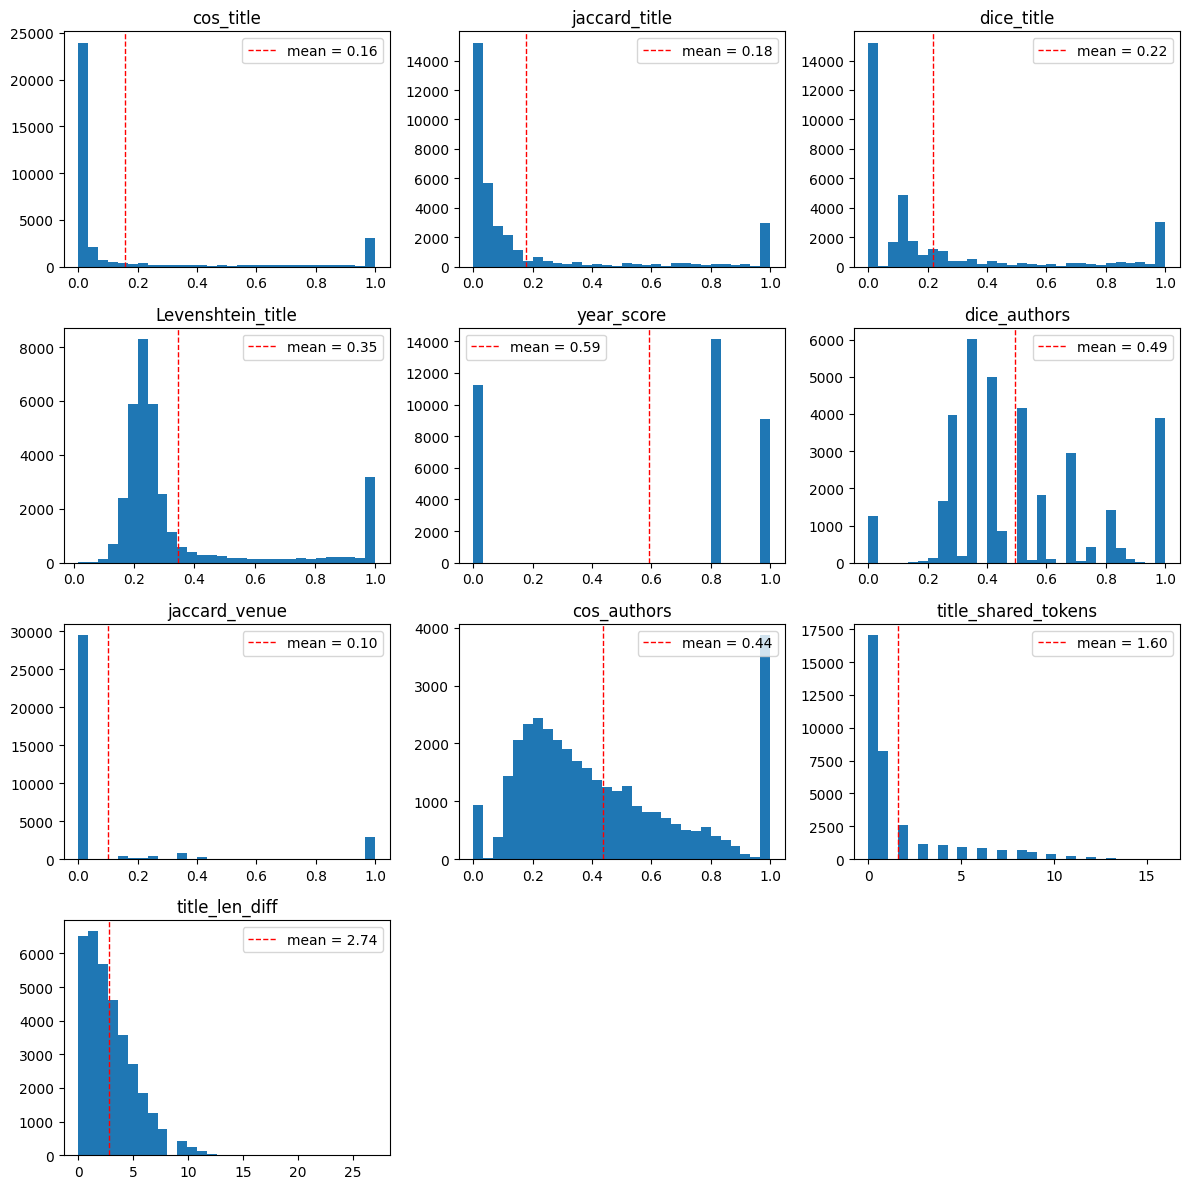

In [13]:
# Plot and save feature histograms
plot_feature_histograms(df=pairs,features=numeric_features,cols=3,bins=30,save_path="figures/feature_histograms.png")

In [14]:
# handle duplicates
before = len(pairs)
pairs = pairs.drop_duplicates(subset='pair_key').reset_index(drop=True)
print(f'Removed {before - len(pairs)} duplicate rows')

# normalize numeric features
scaler = StandardScaler()
scaled_array = scaler.fit_transform(pairs[numeric_features])

scaled_feature_df = pd.DataFrame(
    scaled_array,
    columns=[f'{c}_scaled' for c in numeric_features],
)

train_df = pd.concat(
    [pairs[['pair_key', 'label']].reset_index(drop=True), scaled_feature_df],
    axis=1,
)

train_df.head()

Removed 0 duplicate rows


,pair_key,label,cos_title_scaled,jaccard_title_scaled,dice_title_scaled,Levenshtein_title_scaled,year_score_scaled,dice_authors_scaled,jaccard_venue_scaled,cos_authors_scaled,title_shared_tokens_scaled,title_len_diff_scaled
0,conf/sigmod/LibkinMW96##7F9iCGggYVgJ,0,-0.493418,-0.575108,-0.679867,-0.355119,0.495936,0.024466,0.836599,0.174574,-0.608499,-0.305222
1,conf/vldb/HammelP02##SU2XS1MVb40J,1,2.640159,2.666361,2.434656,2.579748,0.972779,2.035954,3.222741,2.015077,2.441475,-1.125343
2,conf/vldb/GravanoIJKMS01##w0kVbjS1psIJ,0,-0.477523,-0.404504,-0.368415,-0.207864,-1.411434,-0.199033,-0.356472,0.024026,-0.227252,-0.305222
3,conf/sigmod/GuoSBS03##ho3IAnDHcrcJ,0,-0.290393,-0.076420,0.150672,-0.847301,0.495936,0.311821,-0.356472,0.498988,0.153994,-0.715283
4,conf/vldb/WangZL03##SAbNG8szVhQJ,0,-0.493418,-0.575108,-0.679867,-0.415493,0.495936,-0.646030,-0.356472,-1.203989,-0.608499,0.104838


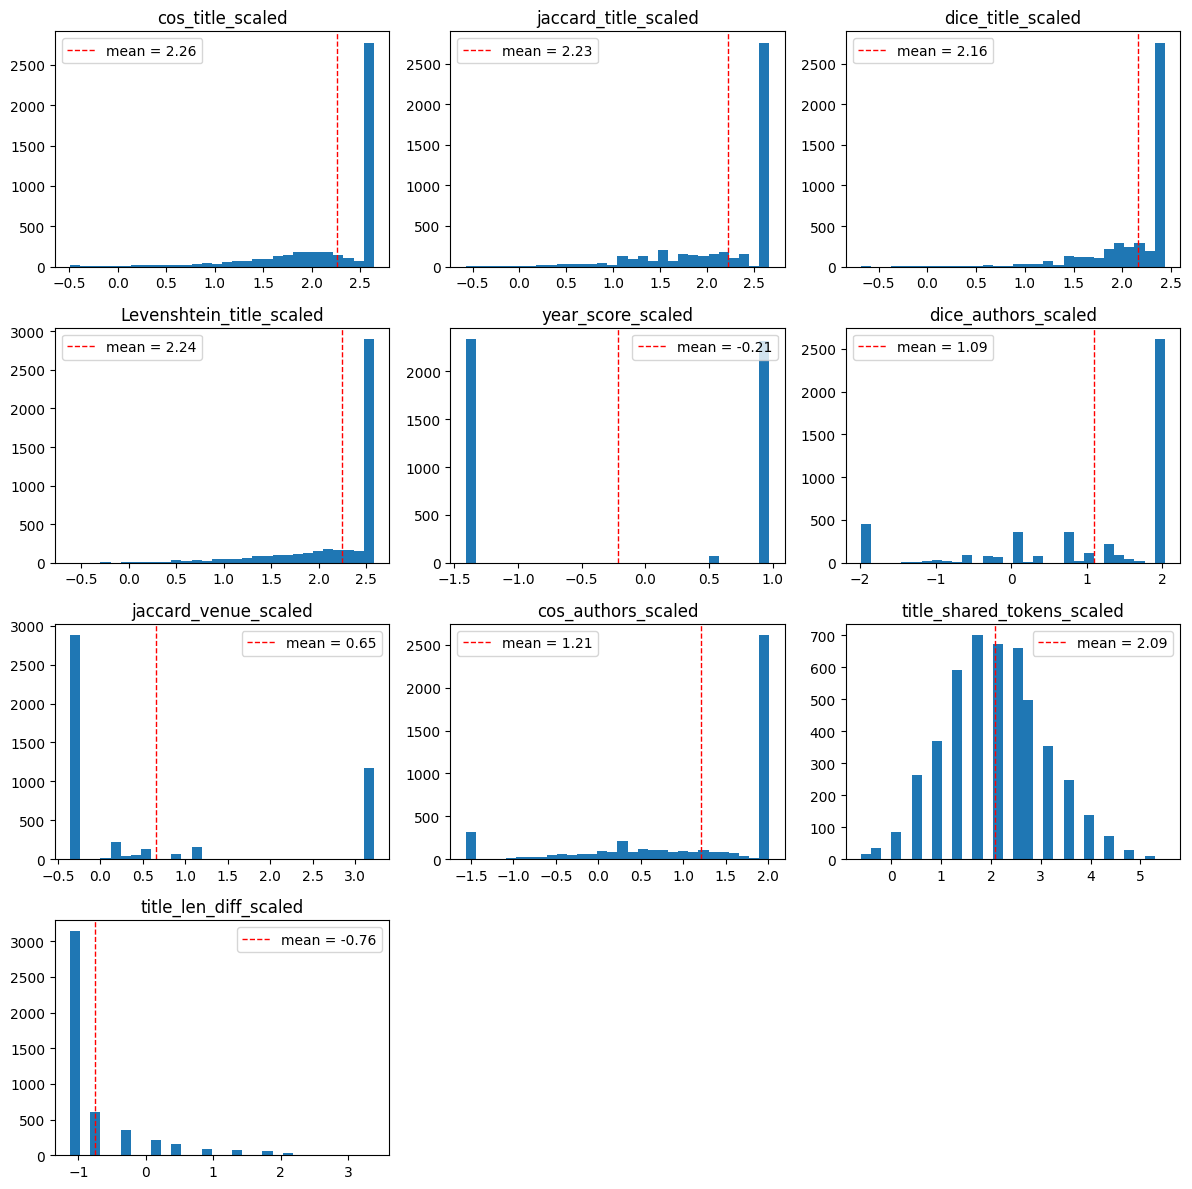

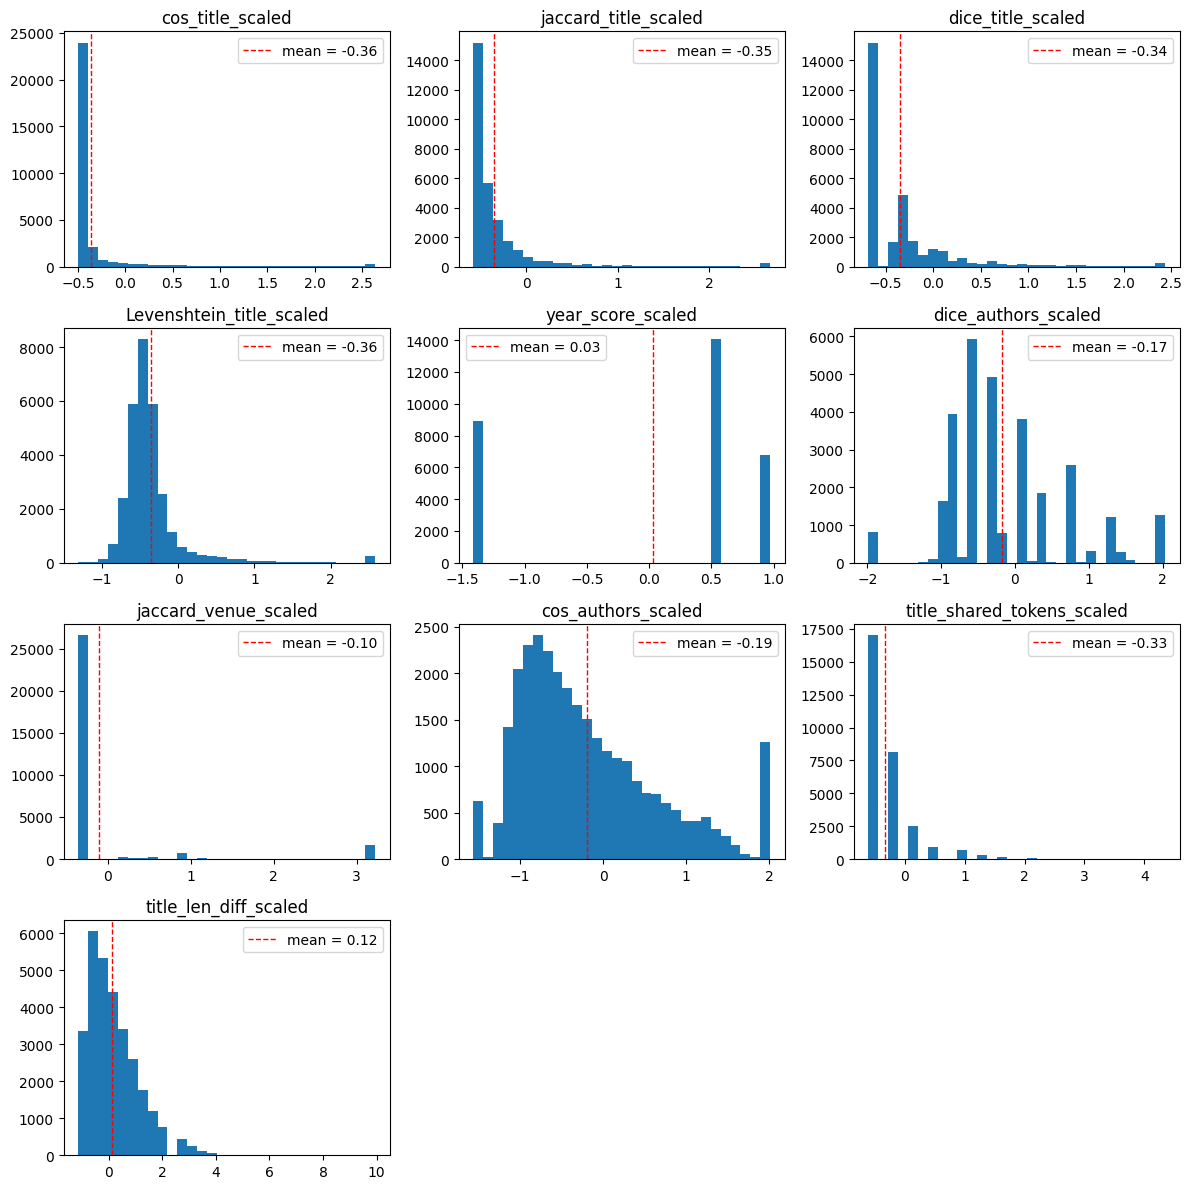

In [15]:
scaled_features = [f"{c}_scaled" for c in numeric_features]

plot_feature_histograms(
    df=train_df[train_df["label"] == 1],
    features=scaled_features,
    cols=3,
    bins=30,
    save_path="figures/scaled_feature_histograms_label1.png"
)

plot_feature_histograms(
    df=train_df[train_df["label"] == 0],
    features=scaled_features,
    cols=3,
    bins=30,
    save_path="figures/scaled_feature_histograms_label0.png"
)

In [16]:
# compute class weights
class_counts = train_df['label'].value_counts()
classes = np.array(sorted(class_counts.index))
class_weights = compute_class_weight(
    class_weight='balanced', classes=classes, y=train_df['label']
)
class_weight_dict = {cls: weight for cls, weight in zip(classes, class_weights)}

print('Class distribution:', class_counts.to_dict())
print('Class weights:', class_weight_dict)


Class distribution: {0: 29782, 1: 4732}
Class weights: {np.int64(0): np.float64(0.5794439594385871), np.int64(1): np.float64(3.64687235841082)}


**// TASK 2.4: Model Training**

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

X = pairs[numeric_features].copy()
y = pairs["label"].astype(int)


scoring = {
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [18]:
# Random Forest model
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        random_state=42,
        n_jobs=1,
        class_weight=class_weight_dict
    ))
])

rf_param_grid = {
    "rf__n_estimators": [100, 300, 500],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    scoring=scoring, # precision, recall, f1
    refit="f1",
    cv=cv,
    n_jobs=1
)

rf_grid.fit(X, y)

def get_rf_df(rf_grid):
    return (
        pd.DataFrame(rf_grid.cv_results_)
        .loc[:, [
            "param_rf__n_estimators",
            "param_rf__max_depth",
            "param_rf__min_samples_split",
            "mean_test_precision",
            "mean_test_recall",
            "mean_test_f1",
            "std_test_f1",
        ]]
        .sort_values("mean_test_f1", ascending=False)
        .reset_index(drop=True)
    )


rf_df = get_rf_df(rf_grid)
rf_df


,param_rf__n_estimators,param_rf__max_depth,param_rf__min_samples_split,mean_test_precision,mean_test_recall,mean_test_f1,std_test_f1
0,300,None,2,0.956989,0.963229,0.960085,0.001521
1,300,20,2,0.956395,0.963229,0.959782,0.001514
2,500,20,5,0.947906,0.971893,0.959733,0.002160
3,500,20,2,0.956393,0.962806,0.959565,0.002138
4,500,None,5,0.947847,0.970837,0.959187,0.001933
5,300,None,5,0.948218,0.970414,0.959168,0.001961
6,500,None,2,0.955976,0.962383,0.959145,0.002100
7,100,20,5,0.946915,0.971471,0.959014,0.002115
8,100,None,5,0.947282,0.971048,0.958996,0.001944
9,300,20,5,0.947811,0.970203,0.958859,0.001876


In [19]:
# Folds performance

cv_res = rf_grid.cv_results_
best_idx = rf_grid.best_index_


rf_folds_df = pd.DataFrame({
    "fold": ["Fold 1", "Fold 2", "Fold 3"],
    "f1_score": [
        cv_res["split0_test_f1"][best_idx],
        cv_res["split1_test_f1"][best_idx],
        cv_res["split2_test_f1"][best_idx],
    ],
})


print(rf_folds_df)
print("Mean +- Std:", f"{cv_res['mean_test_f1'][best_idx]:.4f} +- {cv_res['std_test_f1'][best_idx]:.4f}")


     fold  f1_score
0  Fold 1  0.959670
1  Fold 2  0.962121
2  Fold 3  0.958464
Mean +- Std: 0.9601 +- 0.0015


In [20]:
# SVM model

svm_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf",class_weight=class_weight_dict,random_state=42))
])

svm_param_grid = {
    "svm__C": [0.1, 1.0, 10.0],
    "svm__gamma": ["scale", 0.01],
}

svm_grid = GridSearchCV(
    svm_pipe,
    param_grid=svm_param_grid,
    scoring=scoring, # precision, recall, f1
    refit="f1",
    cv=cv,
    n_jobs=1
)

svm_grid.fit(X, y)

def get_svm_df(svm_grid):
    return (
        pd.DataFrame(svm_grid.cv_results_)
        .loc[:, [
            "param_svm__C",
            "param_svm__gamma",
            "mean_test_precision",
            "mean_test_recall",
            "mean_test_f1",
            "std_test_f1",
        ]]
        .sort_values("mean_test_f1", ascending=False)
        .reset_index(drop=True)
    )

svm_df = get_svm_df(svm_grid)
svm_df


,param_svm__C,param_svm__gamma,mean_test_precision,mean_test_recall,mean_test_f1,std_test_f1
0,10.0,scale,0.894849,0.990912,0.940433,0.000678
1,1.0,scale,0.885013,0.993660,0.936190,0.001332
2,10.0,0.01,0.875466,0.993871,0.930918,0.000282
3,1.0,0.01,0.862177,0.994083,0.923442,0.002051
4,0.1,scale,0.859336,0.995351,0.922354,0.000667
5,0.1,0.01,0.853611,0.991758,0.917506,0.003118


**// TASK 2.5: Evaluation**

In [21]:
from joblib import dump
from sklearn.base import clone

# Select the best model
rf_best_row = rf_df.sort_values("mean_test_f1", ascending=False).iloc[0]
svm_best_row = svm_df.sort_values("mean_test_f1", ascending=False).iloc[0]

rf_best_f1 = float(rf_best_row["mean_test_f1"])
svm_best_f1 = float(svm_best_row["mean_test_f1"])

cv_f1 = {"Random Forest": rf_best_f1, "SVM (RBF)": svm_best_f1}
best_name = max(cv_f1, key=cv_f1.get)

print("Best CV mean F1 scores:", cv_f1)
print("Selecting model:", best_name)


# Build chosen pipeline and set it to the best hyperparameters
if best_name == "Random Forest":
    best_pipe = clone(rf_pipe)
    best_pipe.set_params(
        rf__n_estimators=int(rf_best_row["param_rf__n_estimators"]),
        rf__max_depth=None if pd.isna(rf_best_row["param_rf__max_depth"]) else int(rf_best_row["param_rf__max_depth"]),
        rf__min_samples_split=int(rf_best_row["param_rf__min_samples_split"]),
    )
else:
    best_pipe = clone(svm_pipe)
    best_pipe.set_params(
        svm__C=float(svm_best_row["param_svm__C"]),
        svm__gamma=str(svm_best_row["param_svm__gamma"]),
        svm__probability=True,  # enable predict_proba (must be set before fit)
    )


# Fit chosen model on full data
best_pipe.fit(X, y)


# Predict labels
pred_label = best_pipe.predict(X)

if hasattr(best_pipe, "predict_proba"): # Random Forest
    match_score = best_pipe.predict_proba(X)[:, 1]
elif hasattr(best_pipe, "decision_function"): # SVM
    raw = best_pipe.decision_function(X)
    raw_min, raw_max = float(np.min(raw)), float(np.max(raw))
    if raw_max - raw_min < 1e-12:
        match_score = np.zeros_like(raw, dtype=float)
    else:
        match_score = (raw - raw_min) / (raw_max - raw_min)
else:
    match_score = pred_label.astype(float)


# Build predictions dataframe
pred_df = pairs[["pair_key", "dblp_id", "sch_id"]].copy()
pred_df["label"] = y.to_numpy()
pred_df["pred_label"] = pred_label
pred_df["match_score"] = match_score

# Save model and predictions
model_path = "best_model.joblib"
pred_path = "predictions.csv"

dump(best_pipe, model_path)
pred_df.to_csv(pred_path, index=False)

print("Saved model: ", model_path)
print("Saved predictions: ", pred_path)

print("Sample predicted matches:")
print(pred_df[pred_df["pred_label"] == 1].head())


Best CV mean F1 scores: {'Random Forest': 0.9600851305304715, 'SVM (RBF)': 0.9404328392898941}
Selecting model: Random Forest
Saved model:  best_model.joblib
Saved predictions:  predictions.csv
Sample predicted matches:
                                         pair_key  \
1               conf/vldb/HammelP02##SU2XS1MVb40J   
7        journals/sigmod/Cardelli01##UYAoi4DYOXUJ   
19              conf/sigmod/HullZ96##H1E3GuQcoUAJ   
21         conf/vldb/GravanoIJKMS01##iAYjhuQV_qMJ   
23  journals/sigmod/HellersteinHM03##6ussAgzdL6oJ   

                            dblp_id        sch_id  label  pred_label  \
1               conf/vldb/HammelP02  SU2XS1MVb40J      1           1   
7        journals/sigmod/Cardelli01  UYAoi4DYOXUJ      1           1   
19              conf/sigmod/HullZ96  H1E3GuQcoUAJ      1           1   
21         conf/vldb/GravanoIJKMS01  iAYjhuQV_qMJ      1           1   
23  journals/sigmod/HellersteinHM03  6ussAgzdL6oJ      1           1   

    match_score  
1         

In [22]:
# Training on different set of features

numeric_features_strong = [
    'cos_title',
    'jaccard_title',
    'dice_title',
    'Levenshtein_title',
    'dice_authors',
    'cos_authors',
    'title_shared_tokens',
    'title_len_diff',
]

X = pairs[numeric_features_strong].copy()
y = pairs["label"].astype(int)

rf_grid.fit(X, y)

rf_df_strong = get_rf_df(rf_grid)
print(rf_df_strong)

svm_grid.fit(X, y)
svm_df_strong = get_svm_df(svm_grid)
print(svm_df_strong)

    param_rf__n_estimators param_rf__max_depth  param_rf__min_samples_split  \
0                      300                  20                            2   
1                      500                None                            2   
2                      300                None                            2   
3                      500                  20                            5   
4                      500                  20                            2   
5                      500                None                            5   
6                      100                None                            2   
7                      300                  20                            5   
8                      300                None                            5   
9                      100                  20                            2   
10                     100                None                            5   
11                     100                  20      

In [23]:
rf_df_strong

,param_rf__n_estimators,param_rf__max_depth,param_rf__min_samples_split,mean_test_precision,mean_test_recall,mean_test_f1,std_test_f1
0,300,20,2,0.950771,0.961962,0.956313,0.003875
1,500,None,2,0.950774,0.961962,0.956313,0.003618
2,300,None,2,0.950971,0.961751,0.956305,0.003796
3,500,20,5,0.942207,0.970837,0.956294,0.002448
4,500,20,2,0.950174,0.961750,0.955903,0.003825
5,500,None,5,0.941803,0.970415,0.955878,0.002292
6,100,None,2,0.950155,0.961539,0.955792,0.003615
7,300,20,5,0.941964,0.969992,0.955760,0.002539
8,300,None,5,0.941956,0.969781,0.955653,0.002800
9,100,20,2,0.949733,0.961116,0.955371,0.003885


In [24]:
svm_df_strong

,param_svm__C,param_svm__gamma,mean_test_precision,mean_test_recall,mean_test_f1,std_test_f1
0,10.0,scale,0.885606,0.991335,0.935490,0.002235
1,1.0,scale,0.879151,0.993026,0.932622,0.001718
2,10.0,0.01,0.864499,0.993660,0.924590,0.001521
3,0.1,scale,0.860337,0.995774,0.923110,0.002059
4,1.0,0.01,0.861472,0.993449,0.922763,0.002226
5,0.1,0.01,0.851910,0.991758,0.916522,0.003525
